In [1]:
pip install numpy==1.26.4

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.16.1 requires numba<=0.61,>=0.56.0, but you have numba 0.61.2 which is incompatible.
ydata-profiling 4.16.1 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import shap

In [5]:
df = pd.read_excel("annualsupplementarytablesmarch2025.xlsx")

In [7]:
df.head()

,"Crime in England and Wales, Annual Supplementary tables - year ending March 2025",Unnamed: 1
0,Information,Useful links
1,These data tables are published alongside the ...,"Crime in England and Wales, year ending March ..."
2,For dates of future publications please see th...,ONS Release Calendar
3,Data tables shown in this workbook relate to t...,NaN
4,Crime Survey for England and Wales (CSEW) esti...,Quality of estimates from the Crime Survey for...


In [9]:
print(df.head())

print(df.columns)

print(df.info())

  Crime in England and Wales, Annual Supplementary tables - year ending March 2025  \
0                                        Information                                 
1  These data tables are published alongside the ...                                 
2  For dates of future publications please see th...                                 
3  Data tables shown in this workbook relate to t...                                 
4  Crime Survey for England and Wales (CSEW) esti...                                 

                                          Unnamed: 1  
0                                       Useful links  
1  Crime in England and Wales, year ending March ...  
2                               ONS Release Calendar  
3                                                NaN  
4  Quality of estimates from the Crime Survey for...  
Index(['Crime in England and Wales, Annual Supplementary tables - year ending March 2025', 'Unnamed: 1'], dtype='object')
<class 'pandas.core.frame.DataF

In [11]:
df = df.dropna()

In [13]:
label_encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [15]:
target_col = 'Depression_Score'


In [27]:
from sklearn.model_selection import train_test_split

# Remove extra spaces
df.columns = df.columns.str.strip()

# Print columns
print(df.columns.tolist())

# Define target column correctly
target_col = 'Crime in England and Wales, Annual Supplementary tables - year ending March 2025'


# Features
x = df.drop(target_col, axis=1)

# Target
y = df[target_col]

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

['Crime in England and Wales, Annual Supplementary tables - year ending March 2025', 'Unnamed: 1']
Train shape: (4, 1)
Test shape: (2, 1)


In [29]:
model = RandomForestClassifier()

model.fit(x_train, y_train)

RandomForestClassifier()

In [31]:
predictions = model.predict(x_test)

In [33]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklea

In [37]:
importance = model.feature_importances_

feature_names = x.columns

for name, score in zip(feature_names, importance):
    print(name,score)

Unnamed: 1 1.0


In [39]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklea

In [41]:
pip install shap


  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
ydata-profiling 4.16.1 requires numba<=0.61,>=0.56.0, but you have numba 0.61.2 which is incompatible.
ydata-profiling 4.16.1 requires numpy<2.2,>=1.16.0, but you have numpy 2.2.6 which is incompatible.
ydata-profiling 4.16.1 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.


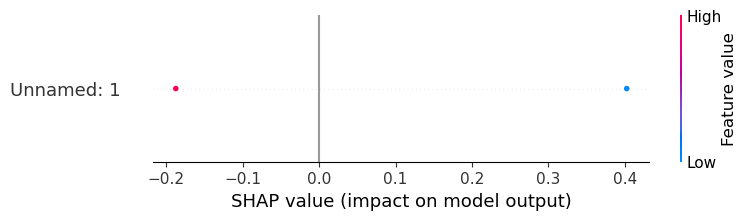

In [45]:
import shap

# Create explainer
explainer = shap.Explainer(model)

# Generate SHAP values
shap_values = explainer(x_test)

# Plot class 1 explainations
shap.plots.beeswarm(shap_values[:, :, 1])